# Datathon 2026: Sales Forecasting — Technical Pipeline
**Team:** NHLBike 
**Model:** LightGBM with Trend-Normalization & Behavioral Features (Model 35 Logic)

This notebook implements a robust forecasting pipeline for daily `Revenue` and `COGS`. The core strategy involves:
1. **Trend Normalization:** Decoupling long-term growth (2020-2022) from seasonal patterns.
2. **Behavioral Feature Engineering:** Leveraging E-commerce metrics (AOV, Conversion, Sessions) to capture customer dynamics.
3. **Walk-Forward Cross-Validation:** Validating model stability across historical time-folds.
4. **Explainability:** Utilizing SHAP values and Feature Importance to validate business logic.

## 1 — Imports & Configuration

In [9]:
import pandas as pd
import numpy as np
import lightgbm as lgb
import shap
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error, r2_score
import warnings

warnings.filterwarnings('ignore')
plt.style.use('ggplot')
sns.set_palette("viridis")

DATA_DIR = 'raw_data/'
OUT_FILE = 'submission.csv'

## 2 — Data Loading

In [10]:
sales = pd.read_csv(DATA_DIR + 'sales.csv', parse_dates=['Date'])
test = pd.read_csv(DATA_DIR + 'sample_submission.csv', parse_dates=['Date'])
promos = pd.read_csv(DATA_DIR + 'promotions.csv', parse_dates=['start_date', 'end_date'])
traffic = pd.read_csv(DATA_DIR + 'web_traffic.csv', parse_dates=['date'])
orders = pd.read_csv(DATA_DIR + 'orders.csv', parse_dates=['order_date'])
order_items = pd.read_csv(DATA_DIR + 'order_items.csv')

print(f"Training data: {sales['Date'].min().date()} to {sales['Date'].max().date()}")

Training data: 2012-07-04 to 2022-12-31


## 3 — Feature Engineering Pipeline

In [11]:
# --- 3.1. Behavioral Analysis ---
traffic['year'], traffic['month'] = traffic['date'].dt.year, traffic['date'].dt.month
orders['year'], orders['month'] = orders['order_date'].dt.year, orders['order_date'].dt.month

# Monthly Conversion & Sessions
m_stats = pd.merge(
    traffic.groupby(['year', 'month'])['sessions'].sum().reset_index(),
    orders.groupby(['year', 'month'])['order_id'].count().reset_index(),
    on=['year', 'month']
)
m_stats['conv'] = m_stats['order_id'] / m_stats['sessions']
avg_conv = m_stats[m_stats['year'] >= 2019].groupby('month')['conv'].mean().to_dict()
avg_sessions = traffic[traffic['year'] >= 2019].groupby('month')['sessions'].mean().to_dict()

# Monthly Average Order Value (AOV)
order_values = order_items.groupby('order_id')['unit_price'].sum().reset_index()
orders_with_val = pd.merge(orders, order_values, on='order_id')
avg_aov = orders_with_val[orders_with_val['year'] >= 2019].groupby('month')['unit_price'].mean().to_dict()

# Monthly Margin Rate
sales['margin_rate'] = (sales['Revenue'] - sales['COGS']) / sales['Revenue']
avg_margin = sales[sales['Date'].dt.year >= 2019].groupby(sales['Date'].dt.month)['margin_rate'].mean().to_dict()

# --- 3.2. Trend Normalization ---
sales['year'] = sales['Date'].dt.year
annual = sales.groupby('year')[['Revenue', 'COGS']].sum()
recent_years = annual.loc[2020:2022]

growth_rev = (1 + recent_years['Revenue'].pct_change().dropna()).prod() ** (1/2)
growth_cogs = (1 + recent_years['COGS'].pct_change().dropna()).prod() ** (1/2)

base_rev_daily = annual.loc[2022, 'Revenue'] / 365
base_cogs_daily = annual.loc[2022, 'COGS'] / 365

def apply_trend(df):
    df = df.copy()
    df['years_ahead'] = df['Date'].dt.year - 2022
    df['trend_rev'] = base_rev_daily * (growth_rev ** df['years_ahead'])
    df['trend_cogs'] = base_cogs_daily * (growth_cogs ** df['years_ahead'])
    return df

train = apply_trend(sales)
test_df = apply_trend(test)

train['rev_norm'] = train['Revenue'] / train['trend_rev']
train['cogs_norm'] = train['COGS'] / train['trend_cogs']

# --- 3.3. Feature Creation ---
def create_features(df, promos_df):
    df = df.copy()
    df['month'] = df['Date'].dt.month
    df['day'] = df['Date'].dt.day
    df['dow'] = df['Date'].dt.dayofweek
    df['doy'] = df['Date'].dt.dayofyear
    df['quarter'] = df['Date'].dt.quarter
    
    # Cyclical Time Features
    df['sin_doy'] = np.sin(2 * np.pi * df['doy'] / 365.25)
    df['cos_doy'] = np.cos(2 * np.pi * df['doy'] / 365.25)
    
    # Behavioral Mappings
    df['feat_conv'] = df['month'].map(avg_conv)
    df['feat_aov'] = df['month'].map(avg_aov)
    df['feat_margin'] = df['month'].map(avg_margin)
    df['feat_sessions'] = df['month'].map(avg_sessions)
    
    # Domain-Specific Indicators
    df['is_weekend'] = df['dow'].isin([5, 6]).astype(int)
    df['post_2019'] = (df['Date'].dt.year >= 2019).astype(int)
    df['is_payday_period'] = ((df['day'] >= 14) & (df['day'] <= 16) | (df['day'] >= 28)).astype(int)
    df['is_beginning_month'] = (df['day'] <= 5).astype(int)
    df['month_progress'] = df['day'] / df['Date'].dt.days_in_month
    
    # Promotion Context
    p_counts = []
    for d in df['Date']:
        p_counts.append(len(promos_df[(promos_df['start_date'] <= d) & (promos_df['end_date'] >= d)]))
    df['promo_count'] = p_counts
    
    return df

train_features = create_features(train, promos)
test_features = create_features(test_df, promos)

FEATURES = ['month', 'day', 'dow', 'doy', 'quarter', 'sin_doy', 'cos_doy',
            'feat_conv', 'feat_aov', 'feat_margin', 'is_weekend', 'post_2019', 
            'promo_count', 'is_payday_period', 'is_beginning_month', 'month_progress']

# Sample Weighting: Recency Bias
train_features['weight'] = 1.0 + (train_features['Date'].dt.year - 2012) / 10.0
train_features.loc[train_features['Date'].dt.year >= 2019, 'weight'] *= 1.5

val_mask = train_features['Date'].dt.year == 2022
X_train = train_features.loc[~val_mask, FEATURES]
y_rev_train = train_features.loc[~val_mask, 'rev_norm']
y_cogs_train = train_features.loc[~val_mask, 'cogs_norm']
w_train = train_features.loc[~val_mask, 'weight']

X_val = train_features.loc[val_mask, FEATURES]
y_rev_val = train_features.loc[val_mask, 'rev_norm']
y_cogs_val = train_features.loc[val_mask, 'cogs_norm']

## 4 — Walk-Forward Cross Validation

In [12]:
lgb_params = {
    'objective': 'regression',
    'metric': 'mae',
    'n_estimators': 1800,
    'learning_rate': 0.009466191175439549,
    'max_depth': 10,
    'num_leaves': 15,
    'min_child_samples': 5,
    'subsample': 0.8,
    'subsample_freq': 1,
    'colsample_bytree': 0.7,
    'reg_alpha': 0.1,
    'reg_lambda': 5.0,
    'min_split_gain': 0.05,
    'random_state': 42,
    'verbosity': -1,
    'n_jobs': -1
}

cv_folds = [2021, 2022]
results = []

for fold_yr in cv_folds:
    train_idx = train_features['Date'].dt.year < fold_yr
    val_idx = train_features['Date'].dt.year == fold_yr
    
    X_tr, y_tr = train_features.loc[train_idx, FEATURES], train_features.loc[train_idx, 'rev_norm']
    X_va, y_va = train_features.loc[val_idx, FEATURES], train_features.loc[val_idx, 'rev_norm']
    w_tr = train_features.loc[train_idx, 'weight']
    
    fold_model = lgb.LGBMRegressor(**lgb_params)
    fold_model.fit(X_tr, y_tr, sample_weight=w_tr, eval_set=[(X_va, y_va)], callbacks=[lgb.early_stopping(100, verbose=False)])
    
    pred_rev = fold_model.predict(X_va) * train_features.loc[val_idx, 'trend_rev']
    mae = mean_absolute_error(train_features.loc[val_idx, 'Revenue'], pred_rev)
    results.append(mae)
    print(f"Fold {fold_yr} MAE: {mae:,.2f}")

print(f"Average CV MAE: {np.mean(results):,.2f}")

Fold 2021 MAE: 573,824.50
Fold 2022 MAE: 521,087.38
Average CV MAE: 547,455.94


## 5 — Final Model Training

In [13]:
# Splitting for final validation check on 2022
final_val_mask = train_features['Date'].dt.year == 2022

model_rev = lgb.LGBMRegressor(**lgb_params)
model_rev.fit(
    X_train, 
    y_rev_train,
    sample_weight=w_train,
    eval_set=[(X_val, y_rev_val)],
    callbacks=[lgb.early_stopping(150)]
)

model_cogs = lgb.LGBMRegressor(**lgb_params)
model_cogs.fit(
    X_train, 
    y_cogs_train,
    sample_weight=w_train,
    eval_set=[(X_val, y_cogs_val)],
    callbacks=[lgb.early_stopping(150)]
)

Training until validation scores don't improve for 150 rounds
Early stopping, best iteration is:
[1218]	valid_0's l1: 0.162596
Training until validation scores don't improve for 150 rounds
Early stopping, best iteration is:
[1575]	valid_0's l1: 0.170017


,boosting_type,'gbdt'
,num_leaves,15
,max_depth,10
,learning_rate,0.009466191175439549
,n_estimators,1800
,subsample_for_bin,200000
,objective,'regression'
,class_weight,None
,min_split_gain,0.05
,min_child_weight,0.001
,min_child_samples,5


## 6 — Model Explainability

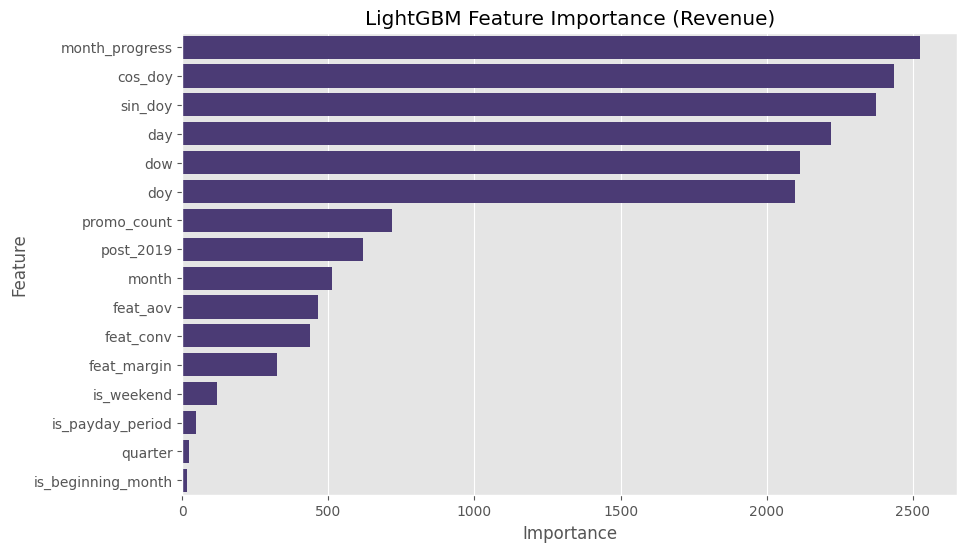

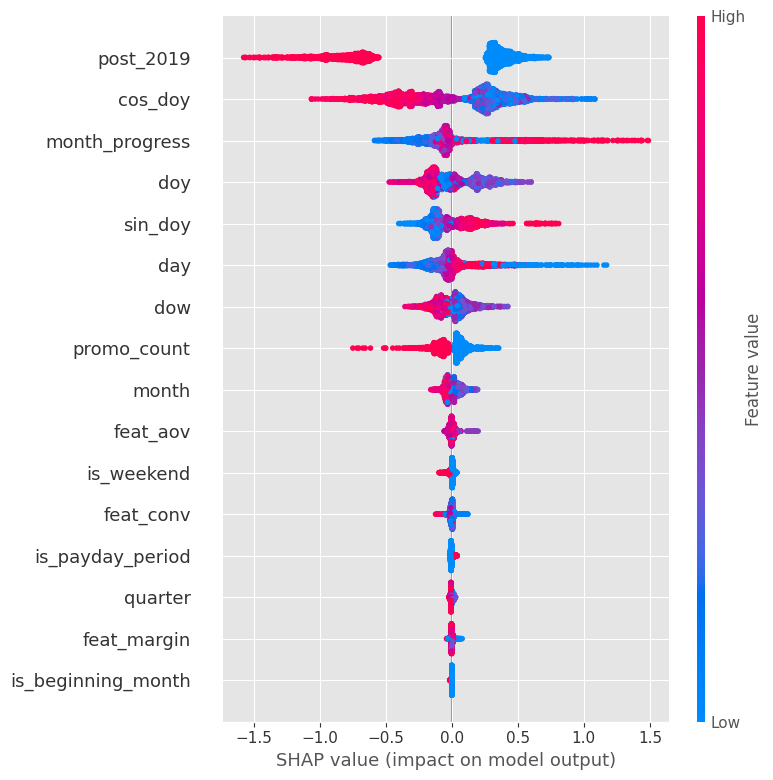

In [14]:
# 6.1. Feature Importance
importance_df = pd.DataFrame({
    'Feature': FEATURES,
    'Importance': model_rev.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df)
plt.title('LightGBM Feature Importance (Revenue)')
plt.show()

# 6.2. SHAP Analysis
explainer = shap.TreeExplainer(model_rev)
shap_values = explainer.shap_values(train_features[FEATURES])

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, train_features[FEATURES], plot_type="dot")

## 7 — Evaluation

In [15]:
val_results = train_features.loc[val_mask].copy()
val_results['Rev_Pred'] = model_rev.predict(X_val) * val_results['trend_rev']
val_results['COGS_Pred'] = model_cogs.predict(X_val) * val_results['trend_cogs']

print("\n" + "="*50)
print(" VALIDATION RESULTS (2022)")
print("="*50)
rev_mae = mean_absolute_error(val_results['Revenue'], val_results['Rev_Pred'])
cogs_mae = mean_absolute_error(val_results['COGS'], val_results['COGS_Pred'])
print(f"Revenue MAE: {rev_mae:.2f}")
print(f"COGS MAE   : {cogs_mae:.2f}")
print(f"Total MAE  : {(rev_mae + cogs_mae)/2:.2f}")


 VALIDATION RESULTS (2022)
Revenue MAE: 521087.38
COGS MAE   : 475310.88
Total MAE  : 498199.13


## 8 — Submission Export

In [16]:
X_test = test_features[FEATURES]
test_features['Revenue'] = (model_rev.predict(X_test) * test_features['trend_rev']).round(2)
test_features['COGS'] = (model_cogs.predict(X_test) * test_features['trend_cogs']).round(2)

# Safety clipping and business logic constraints
test_features['COGS'] = np.maximum(test_features['COGS'], 0)
test_features['COGS'] = np.minimum(test_features['COGS'], test_features['Revenue'] * 1.3) 

submission = test_features[['Date', 'Revenue', 'COGS']]
submission['Date'] = submission['Date'].dt.strftime('%Y-%m-%d')
submission.to_csv(OUT_FILE, index=False)

print(f"Successfully saved {len(submission)} rows to {OUT_FILE}")
submission.head()

Successfully saved 548 rows to submission.csv


,Date,Revenue,COGS
0,2023-01-01,2236761.00,2094168.13
1,2023-01-02,1263180.41,957240.01
2,2023-01-03,1134443.94,852359.78
3,2023-01-04,1041932.83,794832.42
4,2023-01-05,1095796.96,869954.00
